In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data hasil majority voting
df = pd.read_csv('final_majority_voting_results.csv')

In [ ]:
# Daftar aspek utama 
aspects = ['PIGMENTATION', 'LONGEVITY', 'TEXTURE', 'HYDRATION', 'PRICE']

print("--- HASIL ANALISIS STATISTIK SENTIMEN PER ASPEK ---")

summary_data = []

for aspect in aspects:
    # Menghitung distribusi sentimen (termasuk NaN untuk ulasan tanpa aspek tersebut)
    counts = df[aspect].value_counts(dropna=False).rename_axis('Sentiment').reset_index(name='Total')
    counts['Sentiment'] = counts['Sentiment'].fillna('None')
    
    # Menghitung Imbalance Ratio (Hanya untuk label positif, negatif, dan netral)
    actual_sentiments = df[df[aspect].isin(['positive', 'negative', 'neutral'])][aspect].value_counts()
    
    ratio_str = "N/A"  
    if len(actual_sentiments) > 1:
        # ratio dihitung sebagai perbandingan antara jumlah label yang paling banyak dengan yang paling sedikit
        ratio = actual_sentiments.max() / actual_sentiments.min()
        ratio_str = f"{ratio:.2f}:1"
    
    print(f"\nAspek: {aspect}")
    print(counts)
    print(f"Imbalance Ratio: {ratio_str}")

--- HASIL ANALISIS STATISTIK SENTIMEN PER ASPEK ---

Aspek: PIGMENTATION
   Sentiment  Total
0       None   2322
1   positive   1478
2   negative    181
3    neutral    166
4  Ambiguous     33
Imbalance Ratio: 8.90:1

Aspek: LONGEVITY
   Sentiment  Total
0       None   3166
1   positive    558
2   negative    412
3    neutral     40
4  Ambiguous      4
Imbalance Ratio: 13.95:1

Aspek: TEXTURE
   Sentiment  Total
0       None   2346
1   positive   1097
2   negative    482
3    neutral    251
4  Ambiguous      4
Imbalance Ratio: 4.37:1

Aspek: HYDRATION
   Sentiment  Total
0   positive   1903
1       None   1591
2   negative    554
3    neutral    128
4  Ambiguous      4
Imbalance Ratio: 14.87:1

Aspek: PRICE
   Sentiment  Total
0       None   3064
1   positive   1039
2    neutral     41
3   negative     35
4  Ambiguous      1
Imbalance Ratio: 29.69:1


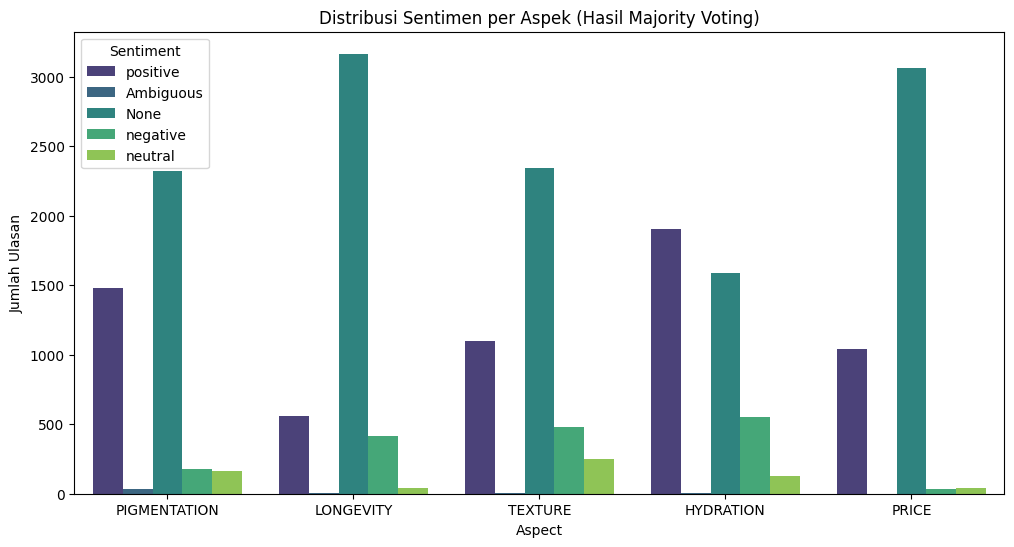

In [11]:
# 2. Visualisasi Distribusi Sentimen
plot_df = df.melt(id_vars=['id'], value_vars=aspects, var_name='Aspect', value_name='Sentiment')
plot_df['Sentiment'] = plot_df['Sentiment'].fillna('None')

plt.figure(figsize=(12, 6))
sns.countplot(data=plot_df, x='Aspect', hue='Sentiment', palette='viridis')
plt.title('Distribusi Sentimen per Aspek (Hasil Majority Voting)')
plt.ylabel('Jumlah Ulasan')
plt.savefig('distribusi_sentimen_aspek.png')